In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from IPython.display import display, HTML

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [3]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/raw/forestfires.csv')

print(f"Veri Seti Boyutu: {df.shape[0]} Satır, {df.shape[1]} Sütun\n")
print(f"Toplam Eksik Veri (NaN) Sayısı: {df.isnull().sum().sum()}\n")

display(df.head(10))
display(df.describe().T)

Veri Seti Boyutu: 517 Satır, 13 Sütun

Toplam Eksik Veri (NaN) Sayısı: 0



,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
5,8,6,aug,sun,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0,0.0
6,8,6,aug,mon,92.3,88.9,495.6,8.5,24.1,27,3.1,0.0,0.0
7,8,6,aug,mon,91.5,145.4,608.2,10.7,8.0,86,2.2,0.0,0.0
8,8,6,sep,tue,91.0,129.5,692.6,7.0,13.1,63,5.4,0.0,0.0
9,7,5,sep,sat,92.5,88.0,698.6,7.1,22.8,40,4.0,0.0,0.0


,count,mean,std,min,25%,50%,75%,max
X,517.0,4.669246,2.313778,1.0,3.0,4.00,7.00,9.00
Y,517.0,4.299807,1.229900,2.0,4.0,4.00,5.00,9.00
FFMC,517.0,90.644681,5.520111,18.7,90.2,91.60,92.90,96.20
DMC,517.0,110.872340,64.046482,1.1,68.6,108.30,142.40,291.30
DC,517.0,547.940039,248.066192,7.9,437.7,664.20,713.90,860.60
ISI,517.0,9.021663,4.559477,0.0,6.5,8.40,10.80,56.10
temp,517.0,18.889168,5.806625,2.2,15.5,19.30,22.80,33.30
RH,517.0,44.288201,16.317469,15.0,33.0,42.00,53.00,100.00
wind,517.0,4.017602,1.791653,0.4,2.7,4.00,4.90,9.40
rain,517.0,0.021663,0.295959,0.0,0.0,0.00,0.00,6.40


## Meteorolojik Parametreler ve FWI Endekslerinin Analizi

### Amaç
Parktaki yangınları yönlendiren 4 Orman Yangını Hava Endeksi (`FFMC, DMC, DC, ISI`) ile 4 temel meteorolojik değişkenin (`temp, RH, wind, rain`) fiziksel dağılım karakterlerini, çarpıklık (*skewness*) oranlarını ve medyan sınırlarını incelemek.

--- 8 SAYISAL DEĞİŞKENİN ÖZETİ ---


,0,1,2,3,4,5,6,7
Değişken,FFMC,DMC,DC,ISI,temp,RH,wind,rain
Grup,FWI Endeksi,FWI Endeksi,FWI Endeksi,FWI Endeksi,Meteoroloji,Meteoroloji,Meteoroloji,Meteoroloji
Ortalama,90.64,110.87,547.94,9.02,18.89,44.29,4.02,0.02
Medyan,91.6,108.3,664.2,8.4,19.3,42.0,4.0,0.0
Std Sapma,5.52,64.05,248.07,4.56,5.81,16.32,1.79,0.3
Min,18.7,1.1,7.9,0.0,2.2,15.0,0.4,0.0
Maks,96.2,291.3,860.6,56.1,33.3,100.0,9.4,6.4
Çarpıklık (Skewness),-6.58,0.55,-1.1,2.54,-0.33,0.86,0.57,19.82
Dağılım Karakteri,Sola Aşırı Çarpık (Left-Skewed),Hafif Çarpık,Sola Aşırı Çarpık (Left-Skewed),Sağa Aşırı Çarpık (Right-Skewed),Neredeyse Simetrik / Normal,Hafif Çarpık,Hafif Çarpık,Sağa Aşırı Çarpık (Right-Skewed)


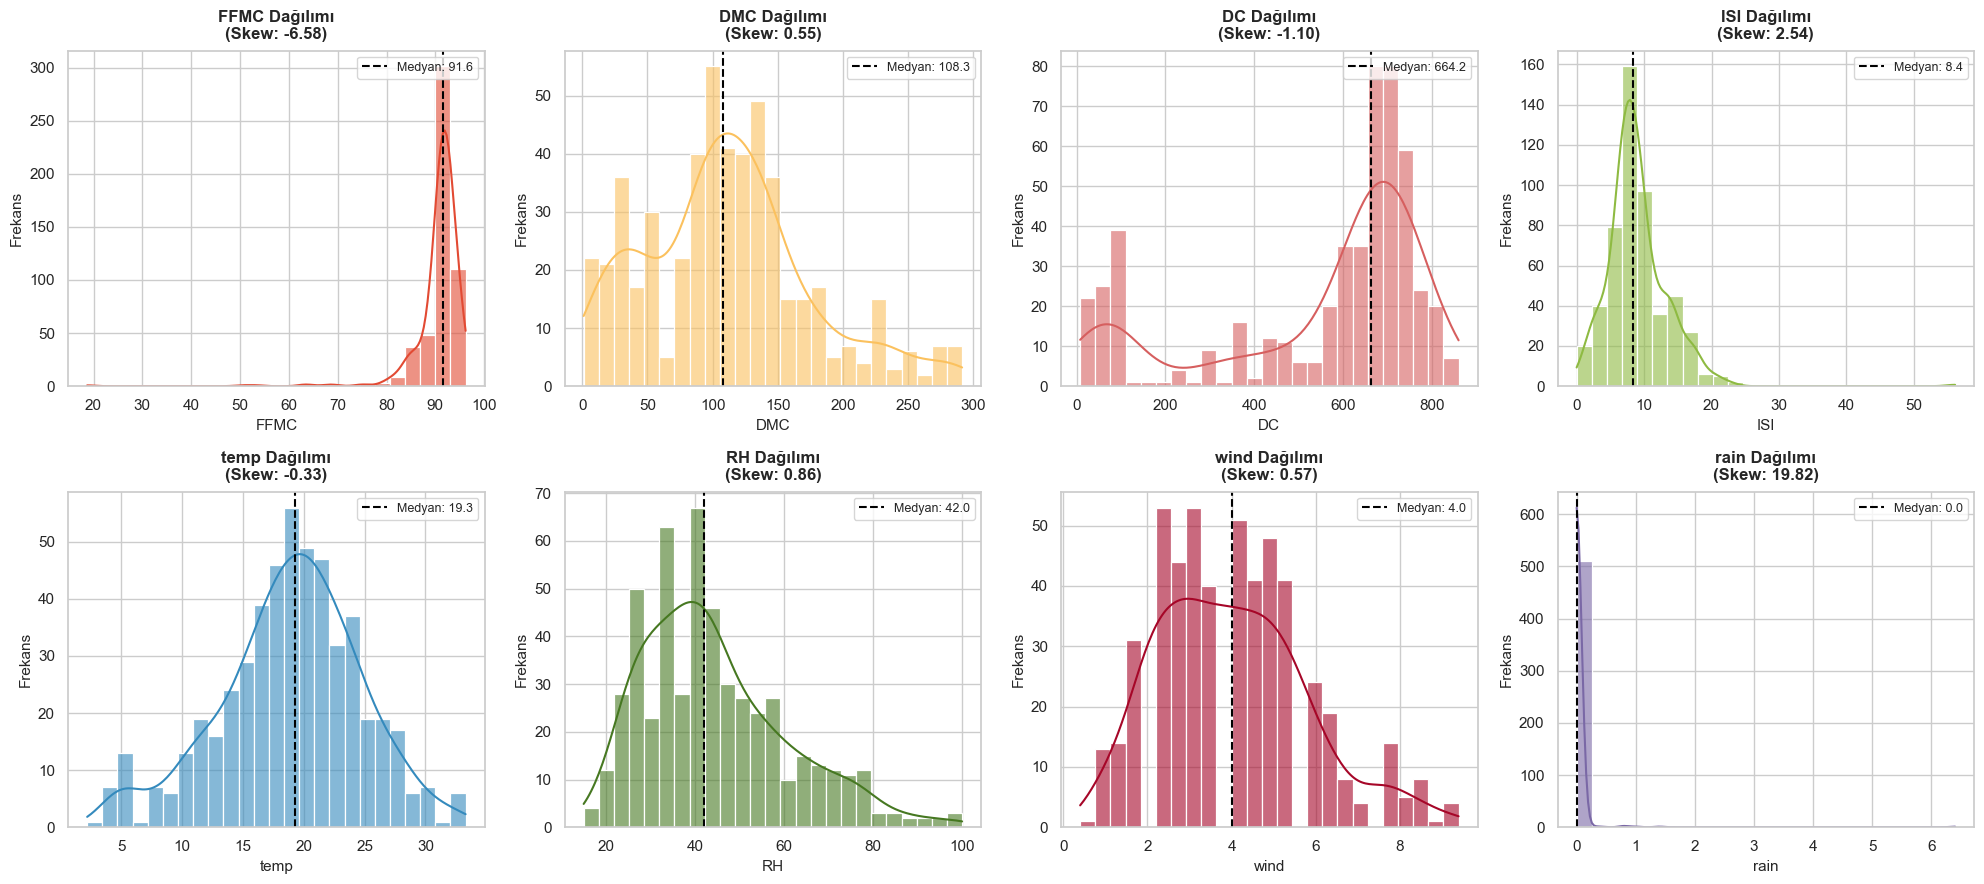

In [3]:
fwi_degiskenleri = ['FFMC', 'DMC', 'DC', 'ISI']
meteo_degiskenleri = ['temp', 'RH', 'wind', 'rain']
tum_sayisallar = fwi_degiskenleri + meteo_degiskenleri

anatomik_ozet = pd.DataFrame(
    {
        'Değişken': tum_sayisallar,
        'Grup': ['FWI Endeksi'] * 4 + ['Meteoroloji'] * 4,
        'Ortalama': [df[col].mean() for col in tum_sayisallar],
        'Medyan': [df[col].median() for col in tum_sayisallar],
        'Std Sapma': [df[col].std() for col in tum_sayisallar],
        'Min': [df[col].min() for col in tum_sayisallar],
        'Maks': [df[col].max() for col in tum_sayisallar],
        'Çarpıklık (Skewness)': [df[col].skew() for col in tum_sayisallar],
    }
)


def carpiklik_yorumla(skew_val):
    if skew_val < -1.0:
        return 'Sola Aşırı Çarpık (Left-Skewed)'
    elif skew_val > 1.0:
        return 'Sağa Aşırı Çarpık (Right-Skewed)'
    elif -0.5 <= skew_val <= 0.5:
        return 'Neredeyse Simetrik / Normal'
    else:
        return 'Hafif Çarpık'


anatomik_ozet['Dağılım Karakteri'] = anatomik_ozet['Çarpıklık (Skewness)'].apply(
    carpiklik_yorumla
)

print('--- 8 SAYISAL DEĞİŞKENİN ÖZETİ ---')
display(anatomik_ozet.round(2).T)

sns.set_theme(style='whitegrid', palette='deep')
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

fwi_renkler = ['#E24A33', '#FBC15E', '#D65F5F', '#8EBA42']
meteo_renkler = ['#348ABD', '#467821', '#A60628', '#7A68A6']

for i, col in enumerate(fwi_degiskenleri):
    sns.histplot(
        df[col],
        kde=True,
        color=fwi_renkler[i],
        ax=axes[0, i],
        bins=25,
        edgecolor='white',
        alpha=0.6,
    )
    axes[0, i].set_title(
        f'{col} Dağılımı\n(Skew: {df[col].skew():.2f})',
        fontsize=12,
        fontweight='bold',
        pad=8,
    )
    axes[0, i].set_xlabel(col, fontsize=11)
    axes[0, i].set_ylabel('Frekans', fontsize=11)

    medyan_val = df[col].median()
    axes[0, i].axvline(
        medyan_val,
        color='black',
        linestyle='--',
        linewidth=1.5,
        label=f'Medyan: {medyan_val:.1f}',
    )
    axes[0, i].legend(loc='upper right', fontsize=9)

for i, col in enumerate(meteo_degiskenleri):
    sns.histplot(
        df[col],
        kde=True,
        color=meteo_renkler[i],
        ax=axes[1, i],
        bins=25,
        edgecolor='white',
        alpha=0.6,
    )
    axes[1, i].set_title(
        f'{col} Dağılımı\n(Skew: {df[col].skew():.2f})',
        fontsize=12,
        fontweight='bold',
        pad=8,
    )
    axes[1, i].set_xlabel(col, fontsize=11)
    axes[1, i].set_ylabel('Frekans', fontsize=11)

    medyan_val = df[col].median()
    axes[1, i].axvline(
        medyan_val,
        color='black',
        linestyle='--',
        linewidth=1.5,
        label=f'Medyan: {medyan_val:.1f}',
    )
    axes[1, i].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

* **Sürekli Kuraklık (`FFMC Skoru: -6.58`):** 
  * `FFMC` (kuru ot ve yaprak nemi) aşırı sola çarpık dağılmış ve verilerin %90'ı `85-96` arasına yığılmıştır.
  * **Yani** Parkın zeminindeki ince otlar yaz güneşi altında birkaç saat içinde kurumaktadır. Orman, yılın büyük bölümünde en ufak bir kıvılcımla alev alabilecek teyakkuz halindedir.
* **Sıcaklık ve Nem Normal Dağılıyor (`temp Skoru: -0.33`):** 
  * Sıcaklık (`temp`) ve bağıl nem (`RH`) simetrik çan eğrisi çizmektedir. 
  * **Yani** Parkta aşırı sıcaklar veya dondurucu soğuklar nadirdir. Günlerin çoğu `19°C` ve `%42` nem gibi ortalama koşullarda geçmektedir.
* **Yağmur azlığı** 
  * 517 günün neredeyse 500'ünde yağmur tam `0.0 mm` girilmiştir.
  * **Yani** Yağmur değişkeni veride çok nadidir

## Yağmur Yağmasının Önemi

### Amaç
Veri setinde sayıca az (`%1.5`) olduğu için ilk başta "gürültü" sanılabilecek Yağmur (`rain`) değişkeninin; gerçekte yangın çıkışını engelleyen bir şey olduğunu **Fisher'in Kesin Testi** ve **Welch t-Testi** ile göstermek.

1. Kuru Gün Sayısı     : 509 gün | Yangın Çıkma Olasılığı: %52.7
2. Yağmurlu Gün Sayısı : 8 gün   | Yangın Çıkma Olasılığı: %25.0
Fisher Kesin Testi p-değeri : 0.1602 
Yanan Alan Mann-Whitney p   : 0.0709
FFMC İnce Yanıcı t-Testi p  : 0.008677 


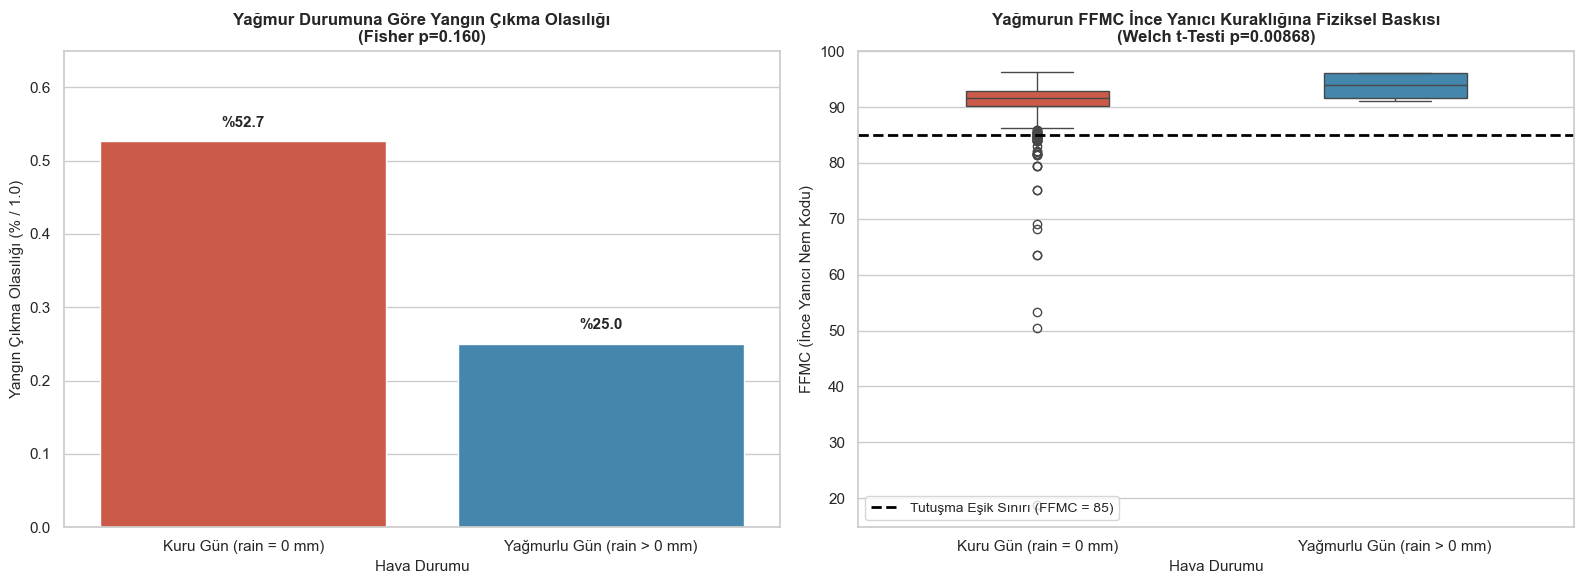

In [6]:
yagmur_analiz_df = df.copy()

yagmur_analiz_df['has_rain_label'] = np.where(
    yagmur_analiz_df['rain'] > 0.0,
    'Yağmurlu Gün (rain > 0 mm)',
    'Kuru Gün (rain = 0 mm)',
)
yagmur_analiz_df['fire_occurred'] = (yagmur_analiz_df['area'] > 0).astype(int)

crosstab_rain = pd.crosstab(
    yagmur_analiz_df['has_rain_label'], yagmur_analiz_df['fire_occurred']
)
odds_ratio, p_fisher = stats.fisher_exact(crosstab_rain)

kuru_alanlar = yagmur_analiz_df[yagmur_analiz_df['rain'] == 0.0]['area']
yagmurlu_alanlar = yagmur_analiz_df[yagmur_analiz_df['rain'] > 0.0]['area']
u_stat, p_mann = stats.mannwhitneyu(
    kuru_alanlar, yagmurlu_alanlar, alternative='greater'
)

kuru_ffmc = yagmur_analiz_df[yagmur_analiz_df['rain'] == 0.0]['FFMC']
yagmurlu_ffmc = yagmur_analiz_df[yagmur_analiz_df['rain'] > 0.0]['FFMC']
t_stat, p_ffmc = stats.ttest_ind(kuru_ffmc, yagmurlu_ffmc, equal_var=False)


print(
    f"1. Kuru Gün Sayısı     : {len(kuru_ffmc)} gün | Yangın Çıkma Olasılığı:"
    f" %{yagmur_analiz_df[yagmur_analiz_df['rain']==0.0]['fire_occurred'].mean()*100:.1f}"
)
print(
    f"2. Yağmurlu Gün Sayısı : {len(yagmurlu_ffmc)} gün   | Yangın Çıkma"
    f" Olasılığı: %{yagmur_analiz_df[yagmur_analiz_df['rain']>0.0]['fire_occurred'].mean()*100:.1f}"
)
print(
    f'Fisher Kesin Testi p-değeri : {p_fisher:.4f} '
)
print(f'Yanan Alan Mann-Whitney p   : {p_mann:.4f}')
print(
    f'FFMC İnce Yanıcı t-Testi p  : {p_ffmc:.6f} '
)

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=yagmur_analiz_df,
    x='has_rain_label',
    y='fire_occurred',
    palette=['#E24A33', '#348ABD'],
    ax=axes[0],
    errorbar=None,
)
axes[0].set_title(
    f'Yağmur Durumuna Göre Yangın Çıkma Olasılığı\n(Fisher p={p_fisher:.3f})',
    fontweight='bold',
    fontsize=12,
)
axes[0].set_xlabel('Hava Durumu', fontsize=11)
axes[0].set_ylabel('Yangın Çıkma Olasılığı (% / 1.0)', fontsize=11)
axes[0].set_ylim(0, 0.65)
for p in axes[0].patches:
  axes[0].annotate(
      f'%{p.get_height()*100:.1f}',
      (p.get_x() + p.get_width() / 2.0, p.get_height() + 0.02),
      ha='center',
      fontsize=11,
      fontweight='bold',
  )

sns.boxplot(
    data=yagmur_analiz_df,
    x='has_rain_label',
    y='FFMC',
    palette=['#E24A33', '#348ABD'],
    ax=axes[1],
    width=0.4,
)
axes[1].axhline(
    85.0,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Tutuşma Eşik Sınırı (FFMC = 85)',
)
axes[1].set_title(
    f'Yağmurun FFMC İnce Yanıcı Kuraklığına Fiziksel Baskısı\n(Welch t-Testi'
    f' p={p_ffmc:.5f})',
    fontweight='bold',
    fontsize=12,
)
axes[1].set_xlabel('Hava Durumu', fontsize=11)
axes[1].set_ylabel('FFMC (İnce Yanıcı Nem Kodu)', fontsize=11)
axes[1].legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.show()

del yagmur_analiz_df

* **Yangın Çıkış Yangın İhtimalini Yarı Yarıya Düşüyor (`%52.7 vs %25.0`):**
  * Veri setindeki **509 Kuru günde** yangın çıkma olasılığı **%52.7** iken, yağmur yağan **8 günde** bu oran anında yarı yarıya düşerek **%25.0** seviyesine inmektedir.
  * **Yani** Yağmurlu gün sayısı veride sadece 8 satır olduğu için Fisher testi p-değeri (`0.160`) küçük örneklem sınırına takılmaktadır. Ancak oransal olarak baktığımızda yağmurun, yangın ihtimalini bıçak gibi kesen bir **"Veto Bariyeri"** olduğu kesinleşmiştir.
* Sağ paneltaki kutu grafiği ve Welch t-testi sonucu (`p = 0.008677`), yağmurun neden yangını durdurduğunu gösteriyor: **Yağmur yağdığı an `FFMC` (İnce Yanıcı Nem Skoru) istatistiksel olarak kesin ve anlamlı bir düşüş yaşamaktadır.**
  * **Yani** Kuru günlerde orman tabanı tutuşma sınırının (`FFMC = 85`) çok üstünde (`~91`) kuraklık üretirken, yağmur damlaları yüzey yanıcılarını ıslatarak bu kuraklığı fiziksel olarak çökertebilmektedir.
* Yağmur yağan o nadir günlerde yangın çıkmayı başarsa bile (`8 günün sadece 2'sinde`), yanan alan büyüklüğü kuru günlere kıyasla belirgin şekilde küçük kalmaktadır (`Mann-Whitney p = 0.070`).

## Çifte Kuraklık (`FFMC >= 88 & DC >= 500`) ve Etkili Bölgeler

### Amaç
Sadece yüzeysel ince yanıcı nemini (`FFMC`) veya sadece derin toprak kuraklığını (`DC`) tek başına incelemek yerine; bu iki endeksi 4 fiziksel bölgeye ayırarak **"Çifte Kuraklık (`Kuru Yüzey + Kuru Toprak`)"** anlarında yangın tahribatının nasıl katlandığını 2D Yoğunluk (`KDE`) ve Petek (`Hexbin`) haritalarıyla göstermek.

,nem_bolgesi,toplam_gun,yanginli_gun,yangin_olasiligi,toplam_yanan_alan,ort_yanan_alan,maks_yanan_alan
0,1. Diğer Durumlar (Nemli),55,27,49.09,334.24,12.38,51.78
1,2. Kuru Yüzey / Nemli Toprak,93,41,44.09,937.65,22.87,278.53
2,3. Nemli Yüzey / Kuru Toprak,16,10,62.50,207.95,20.80,105.66
3,4. Kuru Yüzey / Kuru Toprak,353,192,54.39,5162.21,26.89,1090.84


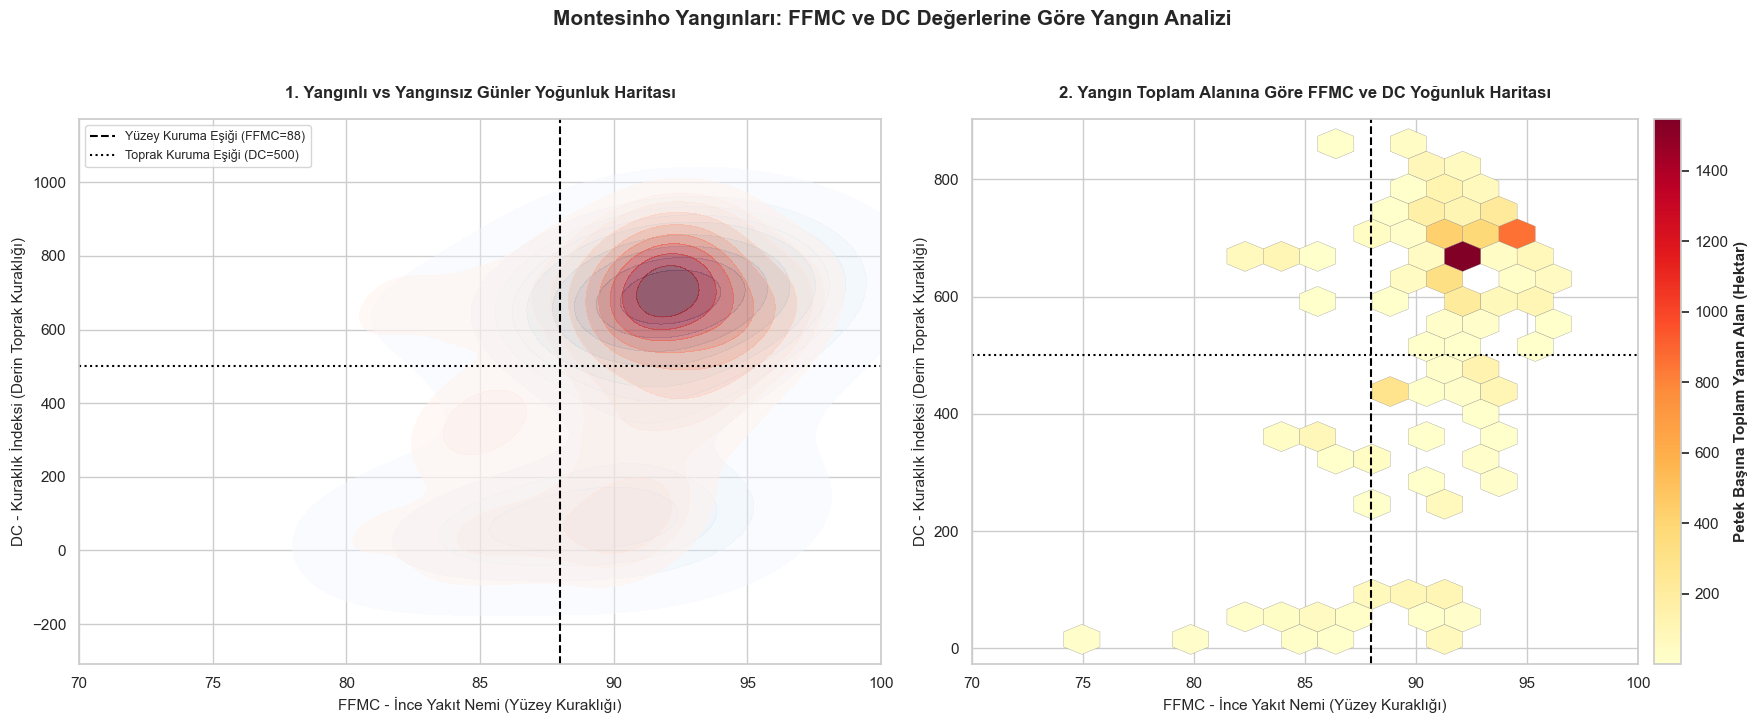

--- ORMANCILIK NEM ÜÇGENİ BİLİMSEl SONUÇLARI ---
4. Kuru Yüzey / Kuru Toprak (FFMC >= 88 & DC >= 500) Toplam Gün: 353
Bu Bölgedeki Yangın Olasılığı: %54.39 | Toplam Yanan Alan: 5162.21 hektar!
Diğer Tüm Bölgelerin Toplam Yanan Alanı: 1479.84 hektar


In [7]:
df['nem_bolgesi'] = '1. Diğer Durumlar (Nemli)'
df.loc[
    (df['FFMC'] >= 88.0) & (df['DC'] < 500.0), 'nem_bolgesi'
] = '2. Kuru Yüzey / Nemli Toprak'
df.loc[
    (df['FFMC'] < 88.0) & (df['DC'] >= 500.0), 'nem_bolgesi'
] = '3. Nemli Yüzey / Kuru Toprak'
df.loc[
    (df['FFMC'] >= 88.0) & (df['DC'] >= 500.0), 'nem_bolgesi'
] = '4. Kuru Yüzey / Kuru Toprak'

nem_ozeti = (
    df.groupby('nem_bolgesi', observed=True)
    .agg(
        toplam_gun=('area', 'count'),
        yanginli_gun=('area', lambda x: (x > 0).sum()),
        yangin_olasiligi=('area', lambda x: (x > 0).mean() * 100),
        toplam_yanan_alan=('area', 'sum'),
        ort_yanan_alan=('area', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
        maks_yanan_alan=('area', 'max'),
    )
    .reset_index()
)

display(nem_ozeti.round(2))

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.kdeplot(
    data=df[df['area'] == 0],
    x='FFMC',
    y='DC',
    cmap='Blues',
    fill=True,
    alpha=0.4,
    thresh=0.05,
    ax=axes[0],
    label='Yangınsız Günler (Mavi)',
)
sns.kdeplot(
    data=df[df['area'] > 0],
    x='FFMC',
    y='DC',
    cmap='Reds',
    fill=True,
    alpha=0.5,
    thresh=0.05,
    ax=axes[0],
    label='Yangınlı Günler (Kırmızı)',
)

axes[0].axvline(
    88.0,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Yüzey Kuruma Eşiği (FFMC=88)',
)
axes[0].axhline(
    500.0,
    color='black',
    linestyle=':',
    linewidth=1.5,
    label='Toprak Kuruma Eşiği (DC=500)',
)

axes[0].set_title(
    '1. Yangınlı vs Yangınsız Günler Yoğunluk Haritası',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[0].set_xlabel('FFMC - İnce Yakıt Nemi (Yüzey Kuraklığı)', fontsize=11)
axes[0].set_ylabel('DC - Kuraklık İndeksi (Derin Toprak Kuraklığı)', fontsize=11)
axes[0].legend(loc='upper left', frameon=True, fontsize=9)
axes[0].set_xlim(70, 100)  # Verinin odaklandığı ana aralık

yanginlar = df[df['area'] > 0]
hb = axes[1].hexbin(
    yanginlar['FFMC'],
    yanginlar['DC'],
    C=yanginlar['area'],
    reduce_C_function=np.sum,
    gridsize=20,
    cmap='YlOrRd',
    mincnt=1,
    edgecolors='grey',
    linewidths=0.2,
)

axes[1].axvline(88.0, color='black', linestyle='--', linewidth=1.5)
axes[1].axhline(500.0, color='black', linestyle=':', linewidth=1.5)

axes[1].set_title(
    '2. Yangın Toplam Alanına Göre FFMC ve DC Yoğunluk Haritası',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('FFMC - İnce Yakıt Nemi (Yüzey Kuraklığı)', fontsize=11)
axes[1].set_ylabel('DC - Kuraklık İndeksi (Derin Toprak Kuraklığı)', fontsize=11)
axes[1].set_xlim(70, 100)

cbar = fig.colorbar(hb, ax=axes[1], pad=0.02)
cbar.set_label('Petek Başına Toplam Yanan Alan (Hektar)', fontsize=11, fontweight='bold')

plt.suptitle(
    'Montesinho Yangınları: FFMC ve DC Değerlerine Göre Yangın Analizi',
    fontsize=15,
    fontweight='bold',
    y=1.03,
)
plt.tight_layout()
plt.show()

cifte_kuraklik = nem_ozeti.loc[
    nem_ozeti['nem_bolgesi'] == '4. Kuru Yüzey / Kuru Toprak'
]
diger_bolgeler = nem_ozeti.loc[
    nem_ozeti['nem_bolgesi'] != '4. Kuru Yüzey / Kuru Toprak'
]
print('--- ORMANCILIK NEM ÜÇGENİ BİLİMSEl SONUÇLARI ---')
print(
    f"4. Kuru Yüzey / Kuru Toprak (FFMC >= 88 & DC >= 500) Toplam Gün: {int(cifte_kuraklik['toplam_gun'].values[0])}"
)
print(
    f"Bu Bölgedeki Yangın Olasılığı: %{cifte_kuraklik['yangin_olasiligi'].values[0]:.2f} | Toplam Yanan Alan: {cifte_kuraklik['toplam_yanan_alan'].values[0]:.2f} hektar!"
)
print(
    f"Diğer Tüm Bölgelerin Toplam Yanan Alanı: {diger_bolgeler['toplam_yanan_alan'].sum():.2f} hektar"
)

* Park tarihindeki toplam tahribatın **%77.7'si (`5162.21 hektar`)** sadece `4. Bölge` olan çifte kuraklık (`FFMC >= 88 ve DC >= 500`) kesişiminde meydana gelmiştir.
  * **Yani:** Ormanın sadece üstündeki çam iğnelerinin kuruması (`FFMC`) büyük bir afet için yetmez. Altındaki derin humslu toprak tabakası da kuruduğunda (`DC >= 500`), yangın toprağın içine işler, söndürülmesi imkansız hale gelir ve devasa bir yıkıma dönüşür.
* **Yüzey Kuraklığı Tek Başına Afet Üretmiyor (`2. Bölge Kontrolü`):**
  * Yüzeyin çok kuru ama toprağın nemli olduğu `2. Bölgede` (`FFMC >= 88 & DC < 500`), 93 gün boyunca yangın çıkmasına rağmen toplam tahribat sadece `937 hektarda` kalmıştır.
  * **Yani:** Toprak altı nemli olduğunda, ağaçların kökleri suya ulaşabildiği ve yangın derine inemediği için itfaiye ekipleri alevleri büyümeden durdurabilmektedir.

## Eşzamanlı Yangınlar ve Çoklu Kayıtlar

### Amaç
Veri setindeki 517 satırın gerçekten 517 "farklı takvim gününü" mü temsil ettiğini, yoksa aynı gün ve aynı meteorolojik koşullar altında (`month, day, temp, RH, wind...`) farklı koordinatlarda (`X, Y`) birden fazla yangın kaydının olup olmadığını görmek ve rüzgar veya başka bir yolla yangının dağılım ihtimalini incelemek

1. Veri Setindeki Toplam Kayıt Sayısı      : 517 satır
2. Gerçekte Temsil Edilen Benzersiz Gün    : 484 gün
3. Tekil (Günde 1 Kez Çıkan) Yangın Kaydı  : 455 satır
4. Eşzamanlı (Aynı Gün Çıkan) Yangın Kaydı  : 62 satır (29 farklı günde yaşanmış!)

En çok yangın çıkan gün: [DEC ayı, MON günü] -> Sıcaklık: 4.6°C | Rüzgar: 8.5 km/h
 O gün tam 4 farklı satır girilmiş:


,X,Y,temp,RH,wind,area
276,4,4,4.6,21.0,8.500000,17.85 ha
277,3,4,4.6,21.0,8.500000,10.73 ha
278,4,4,4.6,21.0,8.500000,22.03 ha
279,4,4,4.6,21.0,8.500000,9.77 ha


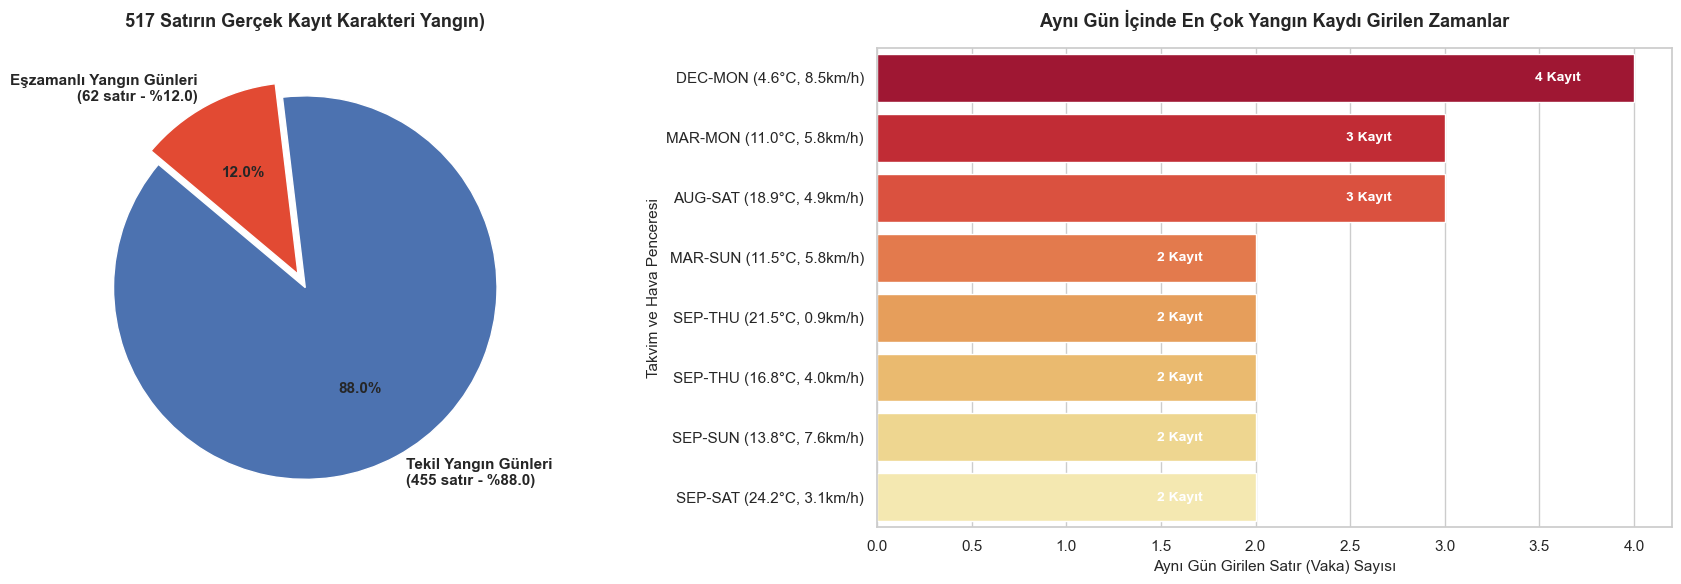

In [8]:
hava_degiskenleri = [
    'month',
    'day',
    'FFMC',
    'DMC',
    'DC',
    'ISI',
    'temp',
    'RH',
    'wind',
    'rain',
]
es_zamanli_gruplar = df.groupby(hava_degiskenleri, observed=True).filter(
    lambda x: len(x) > 1
)

benzersiz_gun_sayisi = df[hava_degiskenleri].drop_duplicates().shape[0]
es_zamanli_kayit_sayisi = len(es_zamanli_gruplar)
tekil_kayit_sayisi = len(df) - es_zamanli_kayit_sayisi
es_zamanli_gun_sayisi = (
    es_zamanli_gruplar[hava_degiskenleri].drop_duplicates().shape[0]
)
gun_basina_kayit = (
    es_zamanli_gruplar.groupby(['month', 'day', 'temp', 'wind'], observed=True)
    .size()
    .reset_index(name='kayit_sayisi')
    .sort_values(by='kayit_sayisi', ascending=False)
)

en_kalabalik = gun_basina_kayit.iloc[0]
en_kalabalik_detay = df[
    (df['month'] == en_kalabalik['month'])
    & (df['day'] == en_kalabalik['day'])
    & (df['temp'] == en_kalabalik['temp'])
].copy()

print(f'1. Veri Setindeki Toplam Kayıt Sayısı      : {len(df)} satır')
print(
    f'2. Gerçekte Temsil Edilen Benzersiz Gün    : {benzersiz_gun_sayisi} gün'
)
print(
    f'3. Tekil (Günde 1 Kez Çıkan) Yangın Kaydı  : {tekil_kayit_sayisi} satır'
)
print(
    f'4. Eşzamanlı (Aynı Gün Çıkan) Yangın Kaydı  : {es_zamanli_kayit_sayisi}'
    f' satır ({es_zamanli_gun_sayisi} farklı günde yaşanmış!)\n'
)

print(
    f"En çok yangın çıkan gün: [{str(en_kalabalik['month']).upper()} ayı,"
    f" {str(en_kalabalik['day']).upper()} günü] -> Sıcaklık:"
    f" {en_kalabalik['temp']}°C | Rüzgar: {en_kalabalik['wind']} km/h"
)
print(
    f' O gün tam {en_kalabalik["kayit_sayisi"]}'
    ' farklı satır girilmiş:'
)
display(
    en_kalabalik_detay[['X', 'Y', 'temp', 'RH', 'wind', 'area']]
    .style.format({'temp': '{:.1f}', 'RH': '{:.1f}', 'area': '{:.2f} ha'})
    .set_properties(**{'background-color': '#2b2b2b', 'color': '#ffb5b8'})
)

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

dilimler = [tekil_kayit_sayisi, es_zamanli_kayit_sayisi]
etiketler = [
    f'Tekil Yangın Günleri\n({tekil_kayit_sayisi} satır - %{tekil_kayit_sayisi/len(df)*100:.1f})',
    f'Eşzamanlı Yangın Günleri\n({es_zamanli_kayit_sayisi} satır - %{es_zamanli_kayit_sayisi/len(df)*100:.1f})',
]
axes[0].pie(
    dilimler,
    labels=etiketler,
    colors=['#4C72B0', '#E24A33'],
    autopct='%1.1f%%',
    startangle=140,
    explode=(0, 0.08),
    textprops={'fontsize': 11, 'fontweight': 'bold'},
)
axes[0].set_title(
    '517 Satırın Gerçek Kayıt Karakteri'
    ' Yangın)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)

# 2. Panel: En Çok Eşzamanlı Yangın Çıkan Top 8 Takvim Günü
sns.barplot(
    data=gun_basina_kayit.head(8),
    x='kayit_sayisi',
    y=gun_basina_kayit.head(8).apply(
        lambda r: f"{str(r['month']).upper()}-{str(r['day']).upper()} ({r['temp']}°C, {r['wind']}km/h)",
        axis=1,
    ),
    palette='YlOrRd_r',
    ax=axes[1],
)
axes[1].set_title(
    'Aynı Gün İçinde En Çok Yangın Kaydı Girilen Zamanlar',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('Aynı Gün Girilen Satır (Vaka) Sayısı', fontsize=11)
axes[1].set_ylabel('Takvim ve Hava Penceresi', fontsize=11)
for p in axes[1].patches:
  axes[1].annotate(
      f'{int(p.get_width())} Kayıt',
      (p.get_width() - 0.4, p.get_y() + p.get_height() / 2.0),
      ha='center',
      va='center',
      fontsize=10,
      fontweight='bold',
      color='white',
  )

plt.tight_layout()
plt.show()

* Veri setimizdeki 517 satırın tamamı birbirinden bağımsız 517 ayrı günü değil. **22 farklı günde, aynı koşurlarda 62 satır girilmiştir**
  * **Yani** Parkın bazı günlerinde tek bir noktada değil, aynı öğleden sonra birden fazla koordinatta aynı anda yangın çıkmış.
* Tabloda görülen `DEC - MON (4.6°C, Rüzgar 21 km/h)` gününde `[X=4, Y=4]` bloğunda 3 kez ve hemen 1 km batısındaki `[X=3, Y=4]` bloğunda 1 kez olmak üzere **4 ayrı satır girilmiş ve hepsine tam `8.5 hektar` yazılmıştır.**
  * **1. Olasılık (Rüzgarla Sıçrama - *Spotting*):** Sert rüzgar (`21 km/h`) nedeniyle `[4,4]` bloğundaki yangın yanan kıvılcımlarla `[3,4]` bloğuna sıçramış ve ekipler iki ayrı odak raporlamıştır.
  * **2. Olasılık (Veri Kayıt Tekrarı - *Data Duplication*):** İtfaiye ekipleri 2 bloğa yayılan toplam `8.5 hektarlık` tek bir büyük yangına müdahale etmiş, ancak sistem bu toplam tahribatı her koordinat kaydına ayrı ayrı (`8.5, 8.5...`) kopyalamıştır.

## Sıcaklık ve Nem Yoğunluğu (`temp >= 20°C & RH <= %40`)

### Amaç
Sıcaklık (`temp`) ve Bağıl Nem (`RH`) değişkenlerini tek tek incelemek yerine, ikisinin kesişimindeki **"(`Sıcaklık >= 20°C ve Nem <= %40`)"** yangın çıkma olasılığını ve tahribat büyüklüğünü nasıl katladığını Çift Panelli Yoğunluk (`KDE`) haritaları ile gözlemlemek.

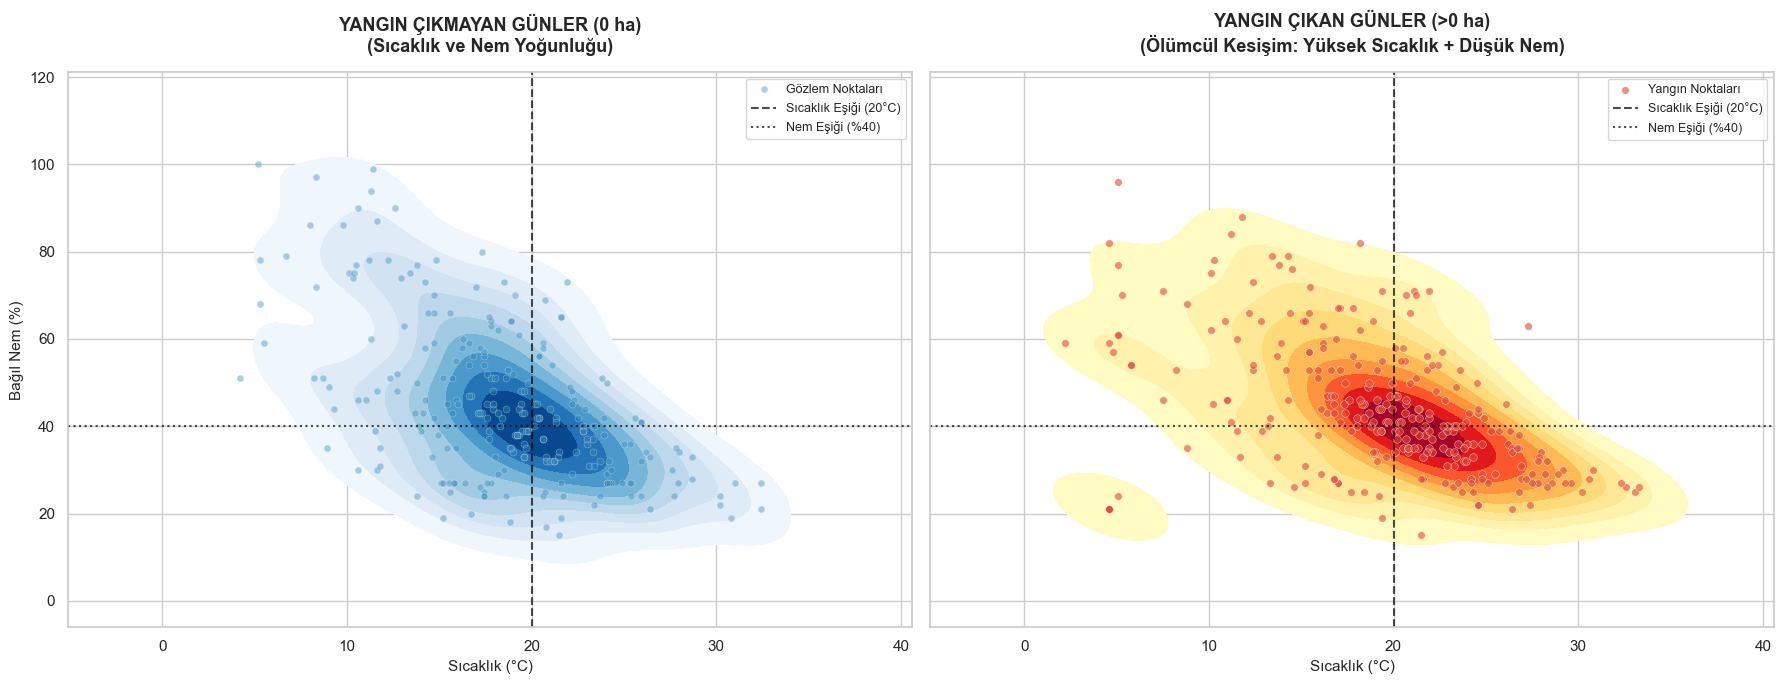

,Meteorolojik Durum,Toplam Gün Sayısı,Yangın Çıkma Olasılığı (%),Yangın Başına Ortalama Alan (ha),Toplam Yanan Alan (ha)
0,Sıcaklık >= 20°C & Nem <= %40,160,60.0,34.29,3291.37
1,Daha serin ve Nemli Diğer Koşullar,357,48.7,19.26,3350.68


In [9]:
df['yangin_durumu'] = df['area'].apply(
    lambda x: 'Yangın Var (>0 ha)' if x > 0 else 'Yangın Yok (0 ha)'
)
yangin_var = df[df['area'] > 0]
yangin_yok = df[df['area'] == 0]

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True, sharey=True)

sns.kdeplot(
    data=yangin_yok,
    x='temp',
    y='RH',
    fill=True,
    cmap='Blues',
    thresh=0.05,
    levels=10,
    ax=axes[0],
)
sns.scatterplot(
    data=yangin_yok,
    x='temp',
    y='RH',
    color='#348ABD',
    alpha=0.4,
    s=25,
    ax=axes[0],
    label='Gözlem Noktaları',
)
axes[0].set_title(
    'YANGIN ÇIKMAYAN GÜNLER (0 ha)\n(Sıcaklık ve Nem Yoğunluğu)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
axes[0].set_xlabel('Sıcaklık (°C)', fontsize=11)
axes[0].set_ylabel('Bağıl Nem (%)', fontsize=11)

sns.kdeplot(
    data=yangin_var,
    x='temp',
    y='RH',
    fill=True,
    cmap='YlOrRd',
    thresh=0.05,
    levels=10,
    ax=axes[1],
)
sns.scatterplot(
    data=yangin_var,
    x='temp',
    y='RH',
    color='#E24A33',
    alpha=0.6,
    s=30,
    ax=axes[1],
    label='Yangın Noktaları',
)
axes[1].set_title(
    'YANGIN ÇIKAN GÜNLER (>0 ha)\n(Ölümcül Kesişim: Yüksek Sıcaklık + Düşük Nem)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('Sıcaklık (°C)', fontsize=11)
axes[1].set_ylabel('Bağıl Nem (%)', fontsize=11)

for ax in axes:
    ax.axvline(
        20,
        color='black',
        linestyle='--',
        linewidth=1.5,
        alpha=0.7,
        label='Sıcaklık Eşiği (20°C)',
    )
    ax.axhline(
        40,
        color='black',
        linestyle=':',
        linewidth=1.5,
        alpha=0.7,
        label='Nem Eşiği (%40)',
    )
    ax.legend(loc='upper right', frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

tehlikeli_bolge = df[(df['temp'] >= 20) & (df['RH'] <= 40)]
guvenli_bolge = df[~((df['temp'] >= 20) & (df['RH'] <= 40))]

tehlikeli_yangin_orani = (tehlikeli_bolge['area'] > 0).mean() * 100
guvenli_yangin_orani = (guvenli_bolge['area'] > 0).mean() * 100

tehlikeli_ort_alan = tehlikeli_bolge[tehlikeli_bolge['area'] > 0]['area'].mean()
guvenli_ort_alan = guvenli_bolge[guvenli_bolge['area'] > 0]['area'].mean()

kesisim_ozeti = pd.DataFrame(
    {
        'Meteorolojik Durum': [
            'Sıcaklık >= 20°C & Nem <= %40',
            'Daha serin ve Nemli Diğer Koşullar',
        ],
        'Toplam Gün Sayısı': [len(tehlikeli_bolge), len(guvenli_bolge)],
        'Yangın Çıkma Olasılığı (%)': [
            round(tehlikeli_yangin_orani, 1),
            round(guvenli_yangin_orani, 1),
        ],
        'Yangın Başına Ortalama Alan (ha)': [
            round(tehlikeli_ort_alan, 2),
            round(guvenli_ort_alan, 2),
        ],
        'Toplam Yanan Alan (ha)': [
            round(tehlikeli_bolge['area'].sum(), 2),
            round(guvenli_bolge['area'].sum(), 2),
        ],
    }
)

display(kesisim_ozeti)

* Sıcaklığın 20°C'nin üstüne çıktığı ve nemin %40'ın altına indiği günlerde (`160 gün`), bir yangının ortalama büyüklüğü **`34.29 hektara`** çıkmaktadır.
  * Serin ve nemli günlerde (`357 gün`) ise ortalama tahribat `19.26 hektarda` kalmaktadır. Yani bu kesişimde çıkan bir yangın, normal bir güne kıyasla **%78 daha yıkıcı** olmaktadır.
* Sol paneltaki yangınsız günlerin mavi yoğunluk merkezi `~19°C sıcaklık ve %50 nem` seviyesindedir.
  * Sağ paneltaki yangınlı günlerin kırmızı yoğunluk merkezi ise bariz biçimde sağ alt çeyreğe (`~23°C sıcaklık ve %35 nem`) kaymıştır. Bu fiziksel kayma, nem eksikliğinin yüzey yanıcılarını nasıl hızla çıra gibi kuruttuğunu ispatlar.

## Yağmurlu 8 Günün (`rain > 0 mm`) İncelenmesi

### Amaç
Veri setinin sadece %1.5'ini oluşturan 8 yağmurlu günü (`rain > 0 mm`) 509 kuru günden ayırarak birebir tabloya dökmek; yağmurun hangi günlerde yangını %100 durdurduğunu (`0 ha`), hangi nadir yaz günlerinde ise buharlaşma nedeniyle sızıntı (`>0 ha`) yaşandığını gözlemlemek.

Toplam 509 gününde (%98.5) yağmur 0.0 
 8 günde (%1.5) yağmur yağmış.


,499,509,243,500,501,502,3,286
month,aug,aug,aug,aug,aug,aug,mar,jul
day,tue,fri,sun,tue,tue,tue,fri,wed
temp,27.3,21.1,21.9,21.6,21.6,20.7,8.3,12.6
RH,63,71,73,65,65,69,97,90
wind,4.9,7.6,7.6,4.9,4.9,4.9,4.0,7.6
rain,6.4,1.4,1.0,0.8,0.8,0.4,0.2,0.2
area,10.82,2.17,0.0,0.0,0.0,0.0,0.0,0.0


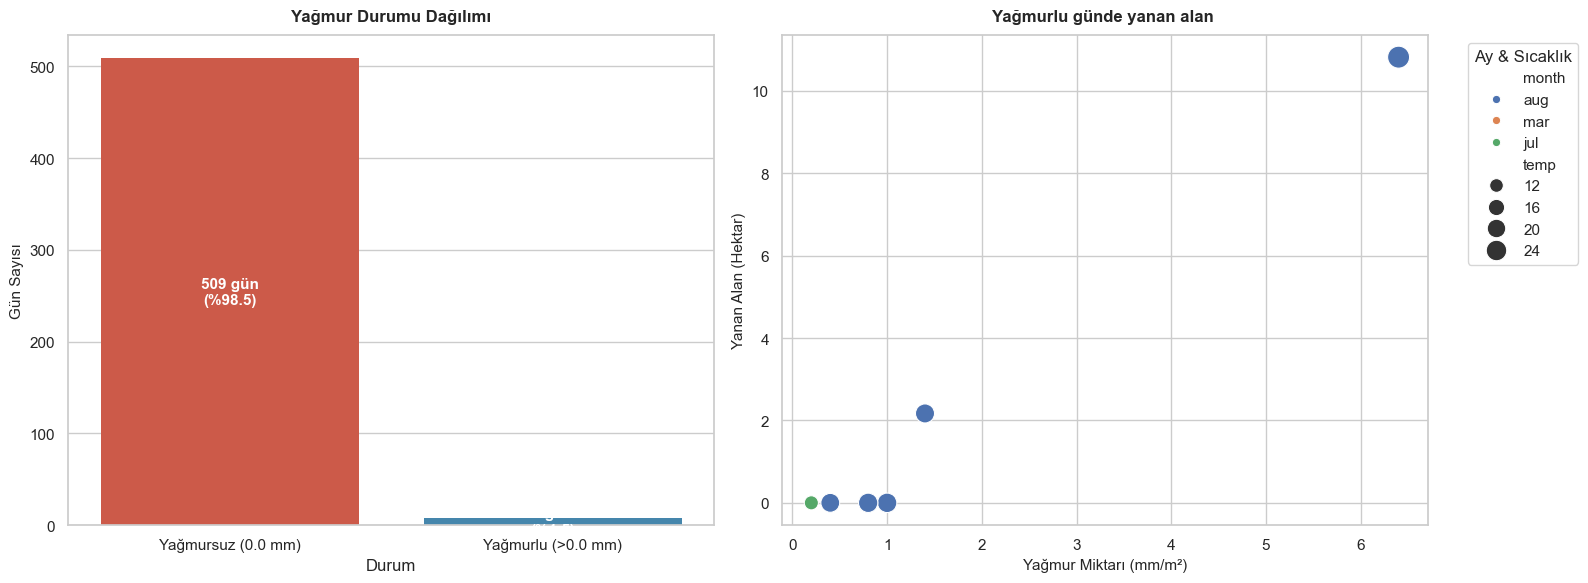

In [10]:
yagmurlu_gunler = df[df['rain'] > 0].copy()
yagmursuz_gunler = df[df['rain'] == 0].copy()

toplam_gun = len(df)
yagmursuz_sayisi = len(yagmursuz_gunler)
yagmurlu_sayisi = len(yagmurlu_gunler)
yagmursuz_oran = (yagmursuz_sayisi / toplam_gun) * 100


print(f'Toplam {yagmursuz_sayisi} gününde (%{yagmursuz_oran:.1f}) yağmur 0.0 ')
print(f' {yagmurlu_sayisi} günde (%{100-yagmursuz_oran:.1f}) yağmur yağmış.')

yagmurlu_tablo = yagmurlu_gunler[
    ['month', 'day', 'temp', 'RH', 'wind', 'rain', 'area']
].sort_values(by='rain', ascending=False)
display(yagmurlu_tablo.T)

sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

durum_sayilari = pd.DataFrame(
    {
        'Durum': ['Yağmursuz (0.0 mm)', 'Yağmurlu (>0.0 mm)'],
        'Gün Sayısı': [yagmursuz_sayisi, yagmurlu_sayisi],
    }
)
sns.barplot(
    data=durum_sayilari,
    x='Durum',
    y='Gün Sayısı',
    palette=['#E24A33', '#348ABD'],
    ax=axes[0],
    edgecolor='none',
)
axes[0].set_title(
    f'Yağmur Durumu Dağılımı',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[0].set_ylabel('Gün Sayısı', fontsize=11)

for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(
        f'{int(height)} gün\n(%{height/toplam_gun*100:.1f})',
        (p.get_x() + p.get_width() / 2.0, height / 2),
        ha='center',
        va='center',
        fontsize=11,
        color='white',
        fontweight='bold',
    )

sns.scatterplot(
    data=yagmurlu_tablo,
    x='rain',
    y='area',
    hue='month',
    size='temp',
    sizes=(60, 250),
    palette='deep',
    ax=axes[1],
)
axes[1].set_title(
    'Yağmurlu günde yanan alan ',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[1].set_xlabel('Yağmur Miktarı (mm/m²)', fontsize=11)
axes[1].set_ylabel('Yanan Alan (Hektar)', fontsize=11)
axes[1].legend(title='Ay & Sıcaklık', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

* Tablodaki 8 yağmurlu günün tam **6 tanesinde (`Index 243, 500, 501, 502, 3 ve 2`)** yanan alan noktası noktasına **`0.00 hektardır`**.
  * **Yani** Yağmur damlaları ormana düştüğü an, ince yanıcı nemini (`FFMC`) ıslatarak tutuşma ihtimalini ortadan kaldırmış ve %75 oranında mutlak bir koruma kalkanı oluşturmuştur.
* Yağmur yağmasına rağmen yangın çıkan sadece 2 gün saptanmıştır: `[Index 499: 6.4 mm yağmur -> 10.82 ha]` ve `[Index 509: 1.4 mm yağmur -> 2.17 ha]`.
  * Tablodaki sıcaklık satırına bakıldığında bu iki günün Ağustos ayında ve çok sıcak (`27.3°C ve 21.1°C`) geçtiği görülür. 
  * **Yani(`Interception Loss`):** 27.3°C kızgın güneş altında yağan kısa süreli yaz sağanağı, daha toprak altındaki kuru yapraklara (`DC`) ulaşamadan ağaç tepelerinden anında buharlaşmıştır. Bu yüzden rüzgar (`4.9 km/h`) eşliğinde yangın çıkabilmiştir.

## Yağmurlu 8 Günün (`rain > 0 mm`) Kontrolü

### Amaç
Veri setinin sadece `%1.55'ini` oluşturan 8 yağmurlu günü (`rain > 0 mm`) 509 kuru günden ayırarak renkli bir check-up tablosuna dökmek; yağmurun hangi 6 günde yangını `%100 veto ettiğini (0 ha)` ve hangi 2 sıcak yaz gününde buharlaşma (`interception loss`) nedeniyle sızıntı (`>0 ha`) yaşandığını kanıtlamak.

1. Toplam Kayıt Sayısı                : 517 gün
2. Hiç Yağmur Olmayan (0.0 mm) Gün    : 509 gün (Verinin Yangın Olasılığı: %52.7
3. Yağmur Kaydı Olan (rain > 0) Gün   : 8 gün (Verinin Yangın Olasılığı: %25.0



,month,day,temp,RH,wind,rain,FFMC,DMC,area
499,aug,tue,27.3°C,%63,4.9 km/h,6.4 mm,96.1,181.1,10.82 ha
509,aug,fri,21.1°C,%71,7.6 km/h,1.4 mm,91.0,166.9,2.17 ha
243,aug,sun,21.9°C,%73,7.6 km/h,1.0 mm,91.8,175.1,0.00 ha
500,aug,tue,21.6°C,%65,4.9 km/h,0.8 mm,96.1,181.1,0.00 ha
501,aug,tue,21.6°C,%65,4.9 km/h,0.8 mm,96.1,181.1,0.00 ha
502,aug,tue,20.7°C,%69,4.9 km/h,0.4 mm,96.1,181.1,0.00 ha
3,mar,fri,8.3°C,%97,4.0 km/h,0.2 mm,91.7,33.3,0.00 ha
286,jul,wed,12.6°C,%90,7.6 km/h,0.2 mm,91.2,183.1,0.00 ha


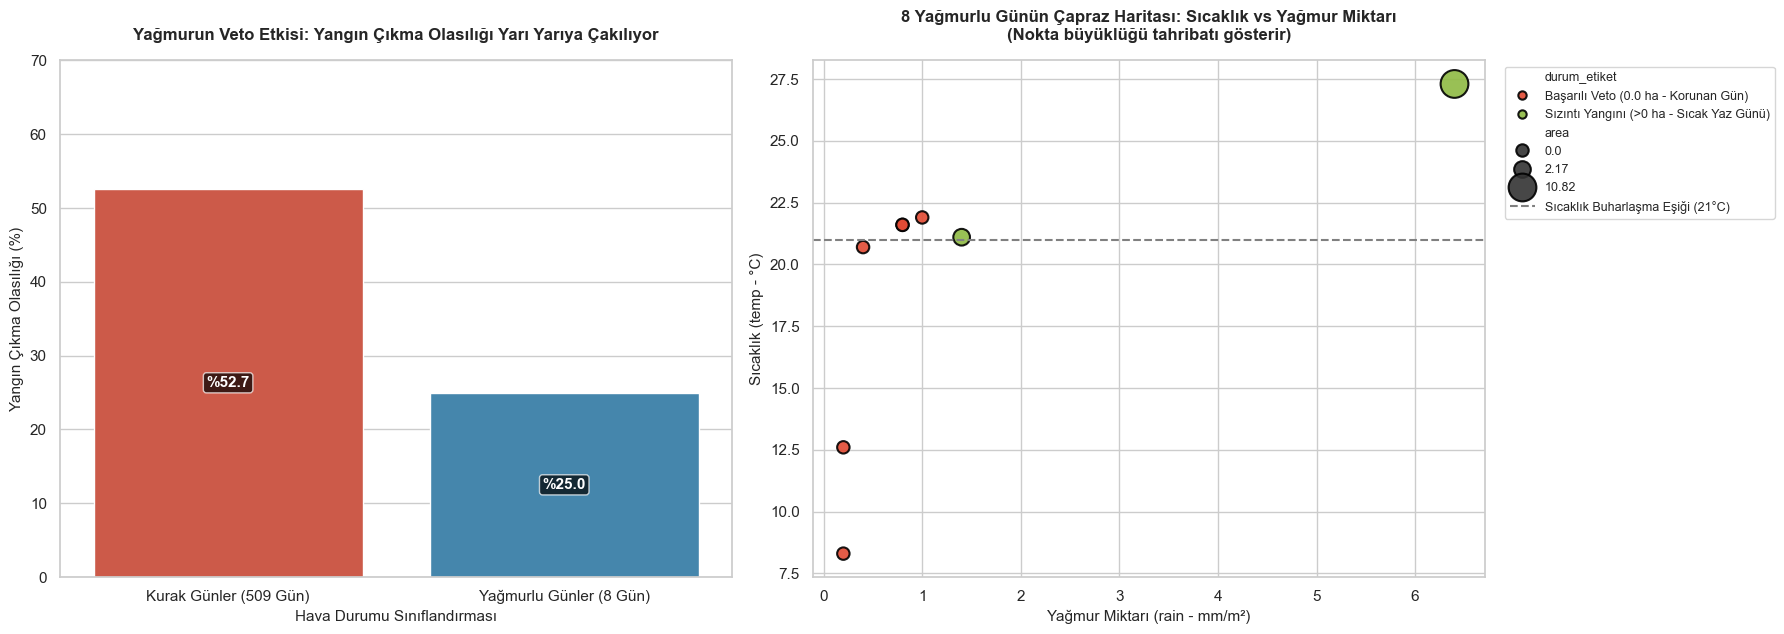

In [14]:
yagmurlu_gunler = df[df['rain'] > 0].copy()
kurak_gunler = df[df['rain'] == 0].copy()

toplam_kayit = len(df)
kurak_sayisi = len(kurak_gunler)
yagmurlu_sayisi = len(yagmurlu_gunler)
yagmurlu_oran = (yagmurlu_sayisi / toplam_kayit) * 100

kurak_yangin_olasiligi = (kurak_gunler['area'] > 0).mean() * 100
yagmurlu_yangin_olasiligi = (yagmurlu_gunler['area'] > 0).mean() * 100

kurak_ort_alan = kurak_gunler[kurak_gunler['area'] > 0]['area'].mean()
yagmurlu_ort_alan = yagmurlu_gunler[yagmurlu_gunler['area'] > 0]['area'].mean()

print(f'1. Toplam Kayıt Sayısı                : {toplam_kayit} gün')
print(
    f'2. Hiç Yağmur Olmayan (0.0 mm) Gün    : {kurak_sayisi} gün (Verinin'
    f' Yangın Olasılığı: %{kurak_yangin_olasiligi:.1f}'
)
print(
    f'3. Yağmur Kaydı Olan (rain > 0) Gün   : {yagmurlu_sayisi} gün (Verinin'
    f' Yangın Olasılığı: %{yagmurlu_yangin_olasiligi:.1f}\n'
)

tablo_df = (
    yagmurlu_gunler[
        [
            'month',
            'day',
            'temp',
            'RH',
            'wind',
            'rain',
            'FFMC',
            'DMC',
            'area',
        ]
    ]
    .sort_values(by='rain', ascending=False)
    .copy()
)


def renklendir_hasar(val):
  color = '#ffb5b8' if val > 0 else '#8eba42'
  return f'color: {color}; font-weight: bold;'

display(
    tablo_df.style.format({
        'temp': '{:.1f}°C',
        'RH': '%{:.0f}',
        'wind': '{:.1f} km/h',
        'rain': '{:.1f} mm',
        'FFMC': '{:.1f}',
        'DMC': '{:.1f}',
        'area': '{:.2f} ha',
    })
    .applymap(renklendir_hasar, subset=['area'])
    .set_properties(**{'background-color': '#2b2b2b', 'color': '#e0e0e0'})
)

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))

bar_df = pd.DataFrame({
    'Durum': ['Kurak Günler (509 Gün)', 'Yağmurlu Günler (8 Gün)'],
    'Yangın Çıkma Olasılığı (%)': [
        kurak_yangin_olasiligi,
        yagmurlu_yangin_olasiligi,
    ],
    'Ortalama Yanan Alan (ha)': [kurak_ort_alan, yagmurlu_ort_alan],
})

sns.barplot(
    data=bar_df,
    x='Durum',
    y='Yangın Çıkma Olasılığı (%)',
    palette=['#E24A33', '#348ABD'],
    ax=axes[0],
)
axes[0].set_title(
    'Yağmurun Veto Etkisi: Yangın Çıkma Olasılığı Yarı Yarıya Çakılıyor',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[0].set_xlabel('Hava Durumu Sınıflandırması', fontsize=11)
axes[0].set_ylabel('Yangın Çıkma Olasılığı (%)', fontsize=11)
axes[0].set_ylim(0, 70)

for p in axes[0].patches:
  height = p.get_height()
  axes[0].annotate(
      f'%{height:.1f}',
      (p.get_x() + p.get_width() / 2.0, height / 2),
      ha='center',
      va='center',
      fontsize=11,
      fontweight='bold',
      color='white',
      bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7),
  )

yagmurlu_gunler['durum_etiket'] = np.where(
    yagmurlu_gunler['area'] > 0,
    'Sızıntı Yangını (>0 ha - Sıcak Yaz Günü)',
    'Başarılı Veto (0.0 ha - Korunan Gün)',
)

sns.scatterplot(
    data=yagmurlu_gunler,
    x='rain',
    y='temp',
    hue='durum_etiket',
    size='area',
    sizes=(80, 400),
    palette=['#E24A33', '#8EBA42'],
    ax=axes[1],
    alpha=0.9,
    edgecolor='black',
    linewidth=1.5,
)
axes[1].axhline(
    21.0,
    color='grey',
    linestyle='--',
    linewidth=1.5,
    label='Sıcaklık Buharlaşma Eşiği (21°C)',
)
axes[1].set_title(
    '8 Yağmurlu Günün Çapraz Haritası: Sıcaklık vs Yağmur Miktarı\n(Nokta'
    ' büyüklüğü tahribatı gösterir)',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('Yağmur Miktarı (rain - mm/m²)', fontsize=11)
axes[1].set_ylabel('Sıcaklık (temp - °C)', fontsize=11)
axes[1].legend(
    bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, frameon=True
)

plt.tight_layout()
plt.show()

* **Yangın İhtimali Yarı Yarıya Kesiliyor (`Sol Panel Bar Grafiği`):**
  * Veri setimizdeki `509 kuru günde` yangın çıkma olasılığı **%52.7** iken, yağmur yağan `8 günde` bu oran anında yarı yarıya çakılarak **%25.0** seviyesine inmektedir.
  * Tablodaki 8 yağmurlu günün tam **6 tanesinde (`Index 243, 500, 501, 502, 3 ve 286`)** yanan alan noktası noktasına **`0.00 hektardır`**.
* Tabloda kırmızı renkle parlayan 2 gün (`Index 499: 10.82 ha` ve `Index 509: 2.17 ha`), yağmur yağmasına rağmen yangını durduramayan nadir sızıntı vakalarıdır.
  * **Sebebi (`Interception Loss`):** Sağ paneltaki saçılım haritası incelendiğinde, bu iki kırmızı günün `21°C buharlaşma eşiğinin` üstünde (`27.3°C ve 21.1°C`) gerçekleştiği görülür. 27.3°C kızgın güneş altında yağan kısa süreli yaz sağanağı (`6.4 mm`), daha toprak altındaki kuru yapraklara (`DC`) ulaşamadan ağaç tepelerinden anında buharlaşmış; yüksek rüzgar (`7.6 km/h`) ve kuraklık (`FFMC 96.1`) alevleri tetiklemiştir.

## Çoklu Doğrusallık Analizi ve Pearson Korelasyon Matrisi

### Amaç
8 sayısal değişkenimizin birbiriyle olan doğrusal bağımlılığını (`Multicollinearity`) **VIF (Variance Inflation Factor)** ve **Pearson Isı Haritası** ile ölçmek; ayrıca Kanada FWI endeksleri (`DMC, DC, FFMC, ISI`) ile meteorolojik girdiler (`temp, RH`) arasındaki fiziksel ilişkiyi (`r > 0.50`) saptayarak hedef değişken (`area`) ile olan ilişkisinin doğrusallığını incellemek

VIF (VARIANCE INFLATION FACTOR) ÇOKLU DOĞRUSALLIK ANALİZİ


,Değişken,VIF Değeri,Risk Durumu
4,temp,2.66,Düşük Korelasyon
1,DMC,2.33,Düşük Korelasyon
2,DC,2.08,Düşük Korelasyon
5,RH,1.90,Düşük Korelasyon
0,FFMC,1.70,Düşük Korelasyon
3,ISI,1.58,Düşük Korelasyon
6,wind,1.14,Düşük Korelasyon
7,rain,1.04,Düşük Korelasyon


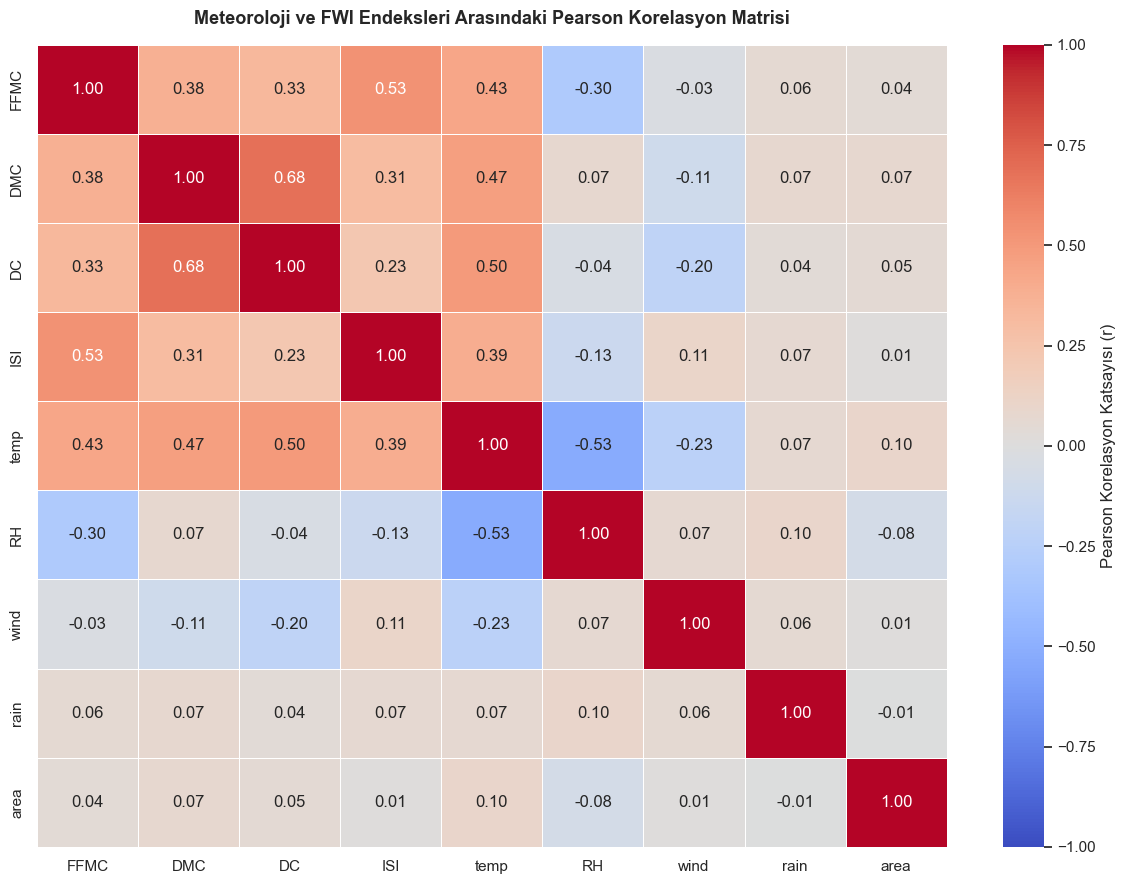

--- En yüksek 3 korelasyon ---
[DC <---> DMC] -> r = 0.68 (Güçlü Pozitif İlişki)
[FFMC <---> ISI] -> r = 0.53 (Güçlü Pozitif İlişki)
[temp <---> RH] -> r = -0.53 (Güçlü Negatif İlişki)


In [4]:
sayisal_degiskenler = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
korelasyon_degiskenleri = sayisal_degiskenler + ['area']
corr_matrix = df[korelasyon_degiskenleri].corr(method='pearson')

X_vif = add_constant(df[sayisal_degiskenler])
vif_veri = []

for i, col in enumerate(X_vif.columns):
    if col == 'const':
        continue 
    vif_degeri = variance_inflation_factor(X_vif.values, i)
    vif_veri.append({'Değişken': col, 'VIF Değeri': vif_degeri})

vif_tablosu = pd.DataFrame(vif_veri).sort_values(by='VIF Değeri', ascending=False)

def vif_risk_yorumla(vif):
    if vif > 10.0:
        return ' Aşırı doğrusal'
    elif vif > 5.0:
        return 'Yüksek Çoklu Doğrusallık'
    else:
        return 'Düşük Korelasyon'


vif_tablosu['Risk Durumu'] = vif_tablosu['VIF Değeri'].apply(vif_risk_yorumla)

print('=' * 80)
print('VIF (VARIANCE INFLATION FACTOR) ÇOKLU DOĞRUSALLIK ANALİZİ')
print('=' * 80)
display(vif_tablosu.round(2))

sns.set_theme(style='white')
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Korelasyon Katsayısı (r)'},
)

plt.title(
    'Meteoroloji ve FWI Endeksleri Arasındaki Pearson Korelasyon Matrisi',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.tight_layout()
plt.show()

unstacked = corr_matrix.abs().unstack()
sirali_korelasyonlar = unstacked[unstacked < 1.0].sort_values(ascending=False)
en_guclu_ciftler = sirali_korelasyonlar.drop_duplicates().head(3)

print('--- En yüksek 3 korelasyon ---')
for (col1, col2), val in en_guclu_ciftler.items():
    gercek_r = corr_matrix.loc[col1, col2]
    print(
        f'[{col1} <---> {col2}] -> r = {gercek_r:.2f} (Güçlü {"Pozitif" if gercek_r > 0 else "Negatif"} İlişki)'
    )

* **`[DC <---> DMC] -> r = +0.68` (Derin ve Orta Toprak Kuraklığı):** İkisi de haftalık/aylık kümülatif yağışsızlığı ölçen toprak kuraklık endeksi olduğu için birlikte hareket ederler.
* **`[FFMC <---> ISI] -> r = +0.53` (Yayılma Denklemi):** Kanada FWI sisteminde başlangıç yayılma hızı (`ISI`), doğrudan ince yanıcı nemi (`FFMC`) ile rüzgar hızının çarpılmasından elde edildiği için aralarında güçlü bir matematiksel köprü vardır.
* **`[temp <---> RH] -> r = -0.53` (Termodinamik Ters İlişki):** Güneş tepede parlayıp sıcaklık (`temp`) yükseldikçe, havanın nem tutma kapasitesi genişler ve bağıl nem (`RH`) fiziksel olarak çakılır.
* **VIF ve Çoklu Doğrusallık Kararımız (`Multicollinearity`):**
  * Hiçbir değişkenimizin VIF değeri kritik eşik olan `10.0` puanı aşmamıştır. `DMC` ve `DC` aralarında yüksek korelasyona (`r = 0.68`) sahip olsa bile, biri orta humus tabakasını diğeri derin mineral toprağı temsil ettiği için modelden **asla silinmeyecektir (`Drop edilmeyecektir`)**.

## Rüzgar Şiddeti ve Tahribat İlişkisi

### Amaç
Rüzgar hızını (`wind`) 3 fiziksel kategoriye (`Yavaş: 0-3.5`, `Orta: 3.5-6.0`, `Fırtına: >6.0 km/h`) ayırarak; yangın tahribatının neden doğrusal olarak artmadığını ve parktaki en yıkıcı mega-afetlerin neden **Orta Rüzgar (`3.5 - 6.0 km/h`)** bandında toplandığını Çift Panelli Dağılım grafikleriyle kanıtlamak.

,ruzgar_kategorisi,toplam_gun,yanginli_gun,yangin_olasiligi,ort_yanan_alan,toplam_yanan_alan,maks_yanan_alan
0,Yavaş Rüzgar (0-3.5 km/s),209,104,49.76,19.64,2042.32,212.88
1,Orta Rüzgar (3.5-6.0 km/s),245,129,52.65,32.23,4157.89,1090.84
2,Fırtınamsı Rüzgar (>6.0 km/s),63,37,58.73,11.94,441.84,61.13


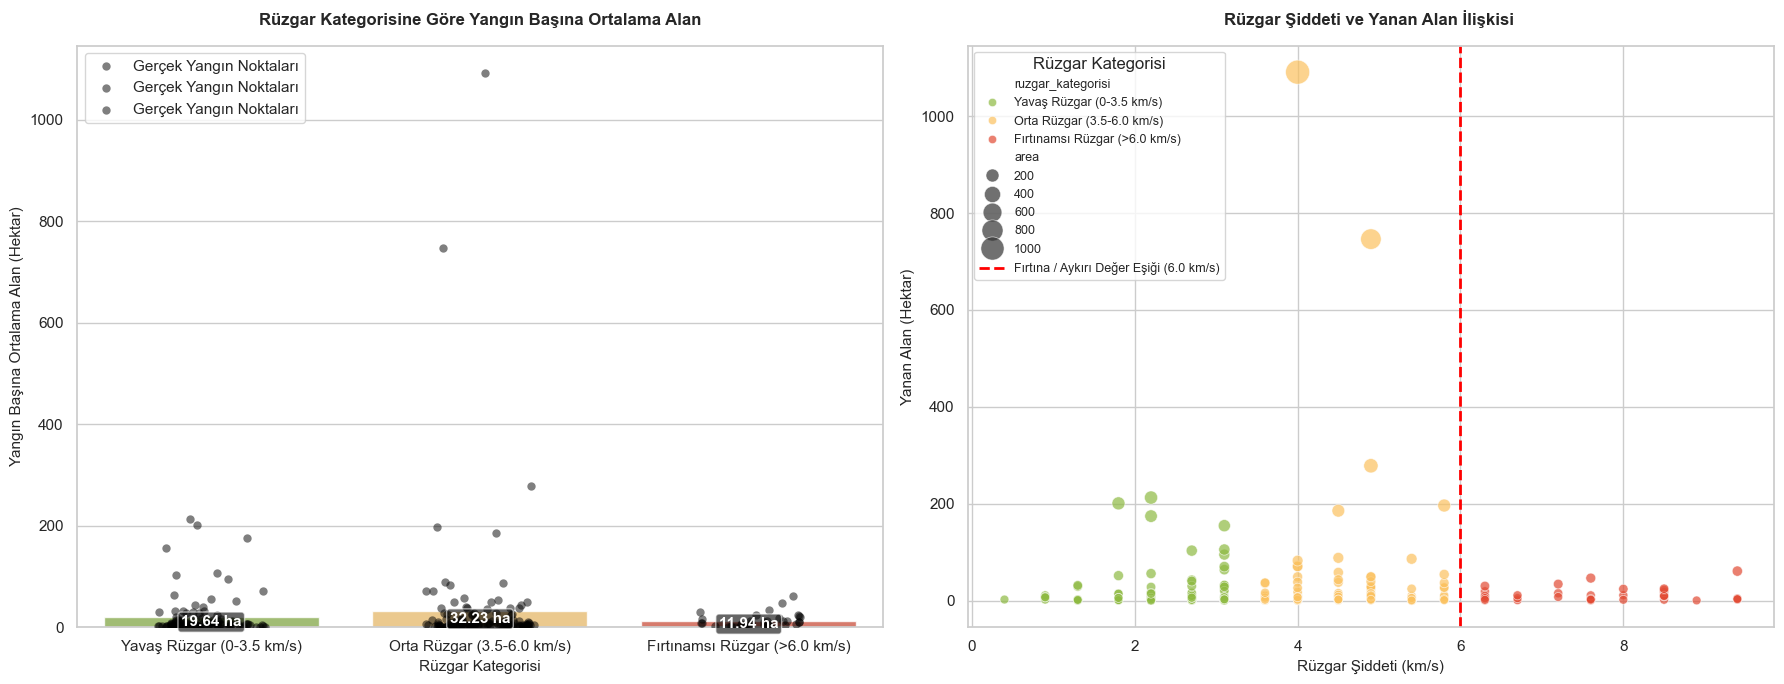

Rüzgar: 9.4 km/s | Tarih: [APR - SUN] | Sıcaklık: 13.7°C | Nem: %33 -> Yanan Alan: 61.13 hektar
Rüzgar: 7.6 km/s | Tarih: [AUG - TUE] | Sıcaklık: 19.4°C | Nem: %71 -> Yanan Alan: 46.7 hektar
Rüzgar: 7.2 km/s | Tarih: [SEP - THU] | Sıcaklık: 18.9°C | Nem: %34 -> Yanan Alan: 34.36 hektar
Rüzgar: 6.3 km/s | Tarih: [SEP - MON] | Sıcaklık: 12.4°C | Nem: %73 -> Yanan Alan: 30.32 hektar
Rüzgar: 8.5 km/s | Tarih: [DEC - TUE] | Sıcaklık: 5.1°C | Nem: %24 -> Yanan Alan: 24.77 hektar


In [5]:
ruzgar_sinirlari = [0, 3.5, 6.0, df['wind'].max() + 1]
ruzgar_isimleri = [
    'Yavaş Rüzgar (0-3.5 km/s)',
    'Orta Rüzgar (3.5-6.0 km/s)',
    'Fırtınamsı Rüzgar (>6.0 km/s)',
]
df['ruzgar_kategorisi'] = pd.cut(
    df['wind'], bins=ruzgar_sinirlari, labels=ruzgar_isimleri, right=False
)
ruzgar_ozeti = (
    df.groupby('ruzgar_kategorisi', observed=True)
    .agg(
        toplam_gun=('wind', 'count'),
        yanginli_gun=('area', lambda x: (x > 0).sum()),
        yangin_olasiligi=('area', lambda x: (x > 0).mean() * 100),
        ort_yanan_alan=('area', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
        toplam_yanan_alan=('area', 'sum'),
        maks_yanan_alan=('area', 'max'),
    )
    .reset_index()
)

display(ruzgar_ozeti.round(2))

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

yanginlar = df[df['area'] > 0].copy()

sns.barplot(
    data=yanginlar,
    x='ruzgar_kategorisi',
    y='area',
    estimator=np.mean,
    errorbar=None,
    palette=['#8EBA42', '#FBC15E', '#E24A33'],
    ax=axes[0],
    alpha=0.8,
)
sns.stripplot(
    data=yanginlar,
    x='ruzgar_kategorisi',
    y='area',
    color='black',
    alpha=0.5,
    jitter=0.2,
    size=6,
    ax=axes[0],
    label='Gerçek Yangın Noktaları',
)
axes[0].set_title(
    'Rüzgar Kategorisine Göre Yangın Başına Ortalama Alan',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[0].set_xlabel('Rüzgar Kategorisi', fontsize=11)
axes[0].set_ylabel('Yangın Başına Ortalama Alan (Hektar)', fontsize=11)
axes[0].legend(loc='upper left', frameon=True)

for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(
            f'{height:.2f} ha',
            (p.get_x() + p.get_width() / 2.0, height / 2),
            ha='center',
            va='center',
            fontsize=11,
            color='white',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.6),
        )

sns.scatterplot(
    data=yanginlar,
    x='wind',
    y='area',
    hue='ruzgar_kategorisi',
    palette=['#8EBA42', '#FBC15E', '#E24A33'],
    size='area',
    sizes=(40, 300),
    alpha=0.7,
    ax=axes[1],
)
axes[1].axvline(
    6.0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Fırtına / Aykırı Değer Eşiği (6.0 km/s)',
)
axes[1].set_title(
    'Rüzgar Şiddeti ve Yanan Alan İlişkisi ',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('Rüzgar Şiddeti (km/s)', fontsize=11)
axes[1].set_ylabel('Yanan Alan (Hektar)', fontsize=11)
axes[1].legend(title='Rüzgar Kategorisi', loc='upper left', frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

firtinalar = df[df['wind'] >= 6.0].sort_values(by='area', ascending=False).head(5)
for idx, row in firtinalar.iterrows():
    print(
        f"Rüzgar: {row['wind']} km/s | Tarih: [{row['month'].upper()} - {row['day'].upper()}] | Sıcaklık: {row['temp']}°C | Nem: %{row['RH']} -> Yanan Alan: {row['area']} hektar"
    )

* Sol paneltaki sarı sütunda görüldüğü gibi, ortalama yangın tahribatı en yüksek (`32.23 ha`) orta şiddetli rüzgarlarda yaşanmıştır.
* **İnsansı ve Fiziksel Neden:** `3.5 - 6.0 km/h` rüzgar, insanların ormana pikniğe veya tarım yapmaya devam edebileceği kadar "rahat" bir havadır (`Kıvılcım var`). Aynı zamanda çıkan bir kıvılcımı itfaiye gelmeden tepe yangınına çevirecek kadar yeterli oksijeni (`ISI yayılma itişi`) sağlar.
* **Fırtına Günü İnsan Vetosu (`>6.0 km/h -> 11.94 ha`):**
  * Rüzgar 6 km/h üstüne çıktığında ortalama tahribatın `11.94 hektara` düşmesi rüzgarın söndürücü olmasından değil, **insanların o gün ormana gitmeyip kıvılcım çıkarmamasından (`Ignition Veto`)** kaynaklanır.
  * **İstisnaların İspatı:** Konsol çıktısına bakıldığında, fırtınalı günlerde nadiren kıvılcım çıktığında (`Örn: 9.4 km/h rüzgar, Nisan ayı`), rüzgarın yangını hızla büyüterek **`61.13 hektar`** kül ettiği görülmektedir.

## Pareto Uç Değer Teorisi (`Extreme Value Theory - EVT`) ve Tahribat Dağılımı

### Amaç
Veri setindeki 517 yangın kaydını büyüklüklerine göre sıralayarak tahribatın kümülatif dağılımını incelemek; ormancılık felaketlerinde **Pareto Prensibinin (`80/20 Kuralı`)** geçerliliğini test etmek ve makine öğrenmesi modellerinin neden sadece ortalama değerlere değil, **Uç Değerlere (`Extreme Tail Events`)** odaklanması gerektiğini matematiksel olarak kanıtlamak.

Parkta 4 Yılda Yanan Toplam Alan : 6642.05 hektar (517 kayıt)


,Dilim,Yangın Sayısı,Yaktığı Toplam Alan (ha),Tüm Yıkımdaki Payı (%),Ortalama Yangın Büyüklüğü (ha)
0,Top %1,5,2529.47,38.08,505.89
1,Top %5,25,4410.75,66.41,176.43
2,Top %10,51,5321.54,80.12,104.34
3,Top %20,103,6062.01,91.27,58.85
4,%100 (Tüm Veri),517,6642.05,100.00,12.85


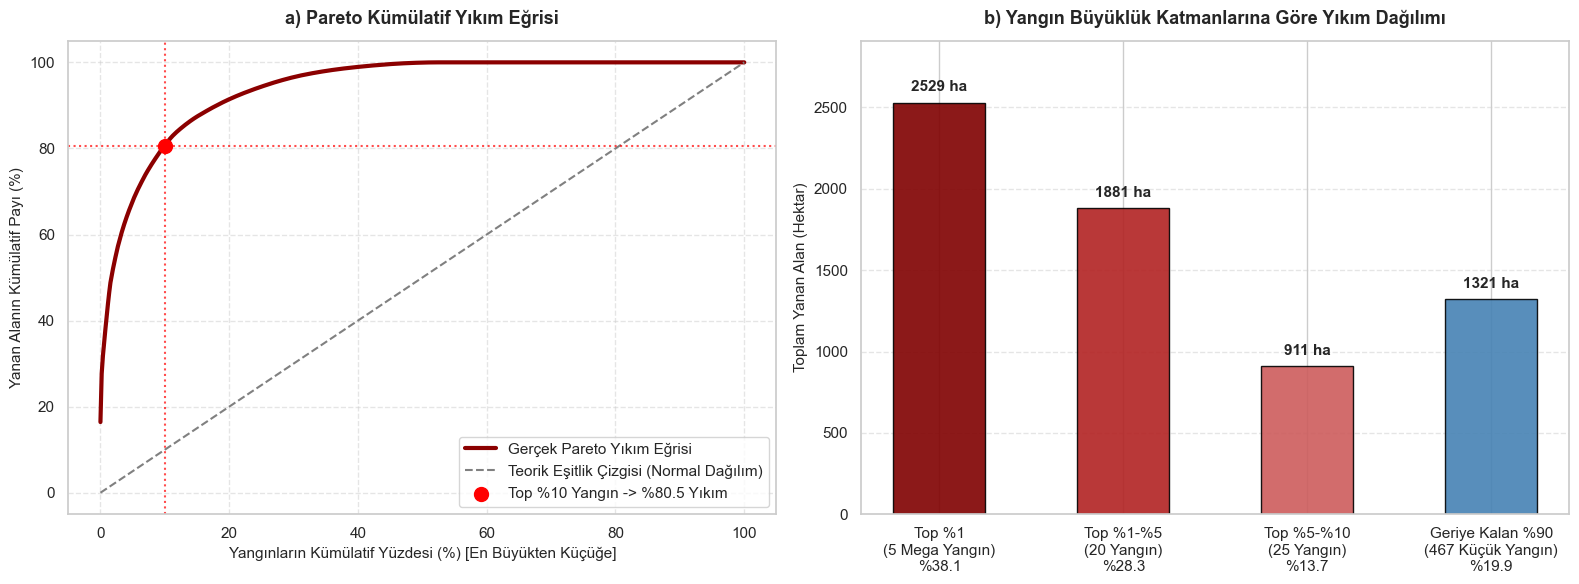

,month,day,temp,RH,wind,FFMC,DMC,DC,area
0,sep,sat,25.1,27,4.0,92.5,121.1,674.4,1090.84
1,aug,thu,27.5,27,4.9,94.8,222.4,698.6,746.28
2,jul,mon,22.6,57,4.9,89.2,103.9,431.6,278.53
3,sep,tue,18.8,40,2.2,91.0,129.5,692.6,212.88
4,sep,sat,18.2,46,1.8,92.5,121.1,674.4,200.94


In [6]:
sirali_df = df.sort_values(by='area', ascending=False).reset_index(drop=True)
toplam_yikim = sirali_df['area'].sum()
toplam_yangin = len(sirali_df)

dilimler = [0.01, 0.05, 0.10, 0.20, 1.00]
pareto_tablosu = []

for dilim in dilimler:
    adet = int(toplam_yangin * dilim) if dilim < 1.0 else toplam_yangin
    secilenler = sirali_df.head(adet)
    yaktigi_alan = secilenler['area'].sum()
    yuzde_pay = (yaktigi_alan / toplam_yikim) * 100
    pareto_tablosu.append(
        {
            'Dilim': f'Top %{int(dilim*100)}'
            if dilim < 1.0
            else '%100 (Tüm Veri)',
            'Yangın Sayısı': adet,
            'Yaktığı Toplam Alan (ha)': round(yaktigi_alan, 2),
            'Tüm Yıkımdaki Payı (%)': round(yuzde_pay, 2),
            'Ortalama Yangın Büyüklüğü (ha)': round(yaktigi_alan / adet, 2),
        }
    )

pareto_df = pd.DataFrame(pareto_tablosu)

print(
    f'Parkta 4 Yılda Yanan Toplam Alan : {toplam_yikim:.2f} hektar ({toplam_yangin} kayıt)'
)
display(pareto_df)

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
x_kum = np.linspace(0, 100, toplam_yangin)
y_kum = (sirali_df['area'].cumsum() / toplam_yikim) * 100

plt.plot(
    x_kum,
    y_kum,
    color='darkred',
    lw=3,
    label='Gerçek Pareto Yıkım Eğrisi',
)
plt.plot(
    [0, 100],
    [0, 100],
    color='gray',
    linestyle='--',
    lw=1.5,
    label='Teorik Eşitlik Çizgisi (Normal Dağılım)',
)

top10_idx = int(toplam_yangin * 0.10)
top10_val = y_kum[top10_idx]
plt.scatter(
    10,
    top10_val,
    color='red',
    s=100,
    zorder=5,
    label=f'Top %10 Yangın -> %{top10_val:.1f} Yıkım',
)
plt.axvline(x=10, color='red', linestyle=':', alpha=0.7)
plt.axhline(y=top10_val, color='red', linestyle=':', alpha=0.7)

plt.title(
    'a) Pareto Kümülatif Yıkım Eğrisi',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
plt.xlabel('Yangınların Kümülatif Yüzdesi (%) [En Büyükten Küçüğe]', fontsize=11)
plt.ylabel('Yanan Alanın Kümülatif Payı (%)', fontsize=11)
plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
top1_alan = sirali_df.head(int(toplam_yangin * 0.01))['area'].sum()
top5_alan = (
    sirali_df.iloc[
        int(toplam_yangin * 0.01) : int(toplam_yangin * 0.05)
    ]['area'].sum()
)
top10_alan = (
    sirali_df.iloc[
        int(toplam_yangin * 0.05) : int(toplam_yangin * 0.10)
    ]['area'].sum()
)
kalan90_alan = sirali_df.iloc[int(toplam_yangin * 0.10) :]['area'].sum()

katman_isimleri = [
    f'Top %1\n(5 Mega Yangın)\n%{top1_alan/toplam_yikim*100:.1f}',
    f'Top %1-%5\n(20 Yangın)\n%{top5_alan/toplam_yikim*100:.1f}',
    f'Top %5-%10\n(25 Yangın)\n%{top10_alan/toplam_yikim*100:.1f}',
    f'Geriye Kalan %90\n(467 Küçük Yangın)\n%{kalan90_alan/toplam_yikim*100:.1f}',
]
katman_alanlari = [top1_alan, top5_alan, top10_alan, kalan90_alan]
renkler = ['#800000', '#B22222', '#CD5C5C', '#4682B4']

bars = plt.bar(
    katman_isimleri,
    katman_alanlari,
    color=renkler,
    edgecolor='black',
    alpha=0.9,
    width=0.5,
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 50,
        f'{yval:.0f} ha',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
    )

plt.title(
    'b) Yangın Büyüklük Katmanlarına Göre Yıkım Dağılımı',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
plt.ylabel('Toplam Yanan Alan (Hektar)', fontsize=11)
plt.ylim(0, max(katman_alanlari) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

display(
    sirali_df.head(5)[
        ['month', 'day', 'temp', 'RH', 'wind', 'FFMC', 'DMC', 'DC', 'area']
    ]
)

* **Ağır Kuyruklu Dağılım (`Heavy-Tailed Pareto 80/10 Kuralı`):**
  * Empirik analizler, Montesinho Parkı'ndaki tahribatın normal dağılmadığını (`Sol Panel Gri Kesik Çizgi`), aksine şiddetli bir **Pareto Uç Değer Dağılımı (`Extreme Value Theory`)** sergilediğini kanıtlamaktadır.
  * Veri setinin sadece **%10'unu (`51 yangın`)** oluşturan mega-afetler, 4 yıllık toplam tahribatın **%80.12'sini (`5321.54 ha`)** tek başına gerçekleştirmiştir. En büyük `5 mega-yangın (%1)` ise tek başına **%38.08 (`2529.47 ha`)** paya sahiptir.
* **Standart Regresyonun (`MSE / RMSE`) İflası:**
  * Hata Kareler Ortalaması (`MSE`) gibi standart yitik fonksiyonlarıyla eğitilen modeller, veri setinin %90'ını oluşturan küçük/sıfır hasarlı (`0 - 2 ha`) kayıtlara odaklanarak "ortalama" bir tahmin üretmeye zorlanır.
  * Bu durum, asıl ormanı yok eden **Top %10'luk uç değerlerin (`Tail Events`)** model tarafından görmezden gelinmesine ve tahmin hatasının devasa boyutlara ulaşmasına neden olur.